# 14 — Capstone: Growth Analytics Dashboard
**Goal:** Build an end-to-end product — load real data, design a narrative,
build the visuals, and ship a Dash app you can open in the browser.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import dash
from dash import dcc, html, dash_table
from dash.dependencies import Input, Output

np.random.seed(99)

## 1. Project brief

**Stakeholder:** VP Marketing.

**Question:** *How is our acquisition performing this quarter, and where
should we reallocate spend?*

**Deliverables:**

1. A static *executive summary* chart (the so what).
2. An interactive Dash dashboard with four views: Overview, Channel, Region,
   Funnel.
3. All code packaged in `src/growth_dashboard/`.

## 2. Step 1 — load and validate the data

We treat the data as production-grade: explicit types, sanity checks, no
silent NaNs.

In [2]:
df = pd.read_csv('data/clean/unified_daily.csv')
print('shape :', df.shape)
print('cols  :', df.columns.tolist())
print('dtypes:')
print(df.dtypes)

shape : (90, 13)
cols  : ['date', 'visits', 'activations', 'otp_total', 'spend', 'impressions', 'clicks', 'paid_conv', 'cvr', 'cpa', 'ctr', 'roas', 'paid_share']
dtypes:
date               str
visits           int64
activations      int64
otp_total        int64
spend          float64
impressions      int64
clicks           int64
paid_conv        int64
cvr            float64
cpa            float64
ctr            float64
roas           float64
paid_share     float64
dtype: object


In [3]:
num = df.select_dtypes('number').columns.tolist()
cat = [c for c in df.columns if df[c].dtype == 'object' or df[c].dtype.name == 'category']
dt  = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
print('numeric  :', num)
print('categorical:', cat)
print('datetime :', dt)
print('\nMissing values:')
print(df.isna().sum())

numeric  : ['visits', 'activations', 'otp_total', 'spend', 'impressions', 'clicks', 'paid_conv', 'cvr', 'cpa', 'ctr', 'roas', 'paid_share']
categorical: []
datetime : []

Missing values:
date           0
visits         0
activations    0
otp_total      0
spend          0
impressions    0
clicks         0
paid_conv      0
cvr            0
cpa            0
ctr            0
roas           0
paid_share     0
dtype: int64


## 3. Step 2 — pick the headline number

The single chart that goes on page 1 of the executive summary. We pick the
first numeric column as the KPI, the first categorical as the breakdown, and
the date column as the time axis.

In [4]:
kpi  = num[0] if num else None
grp  = cat[0] if cat else None
tcol = dt[0]  if dt  else None
print('KPI:', kpi, '| Group:', grp, '| Time:', tcol)

KPI: visits | Group: None | Time: None


In [5]:
# Try to coerce a string date column to datetime
if tcol and not pd.api.types.is_datetime64_any_dtype(df[tcol]):
    try:
        df[tcol] = pd.to_datetime(df[tcol])
        df = df.sort_values(tcol)
    except Exception:
        tcol = None

if tcol and grp:
    monthly = df.groupby([pd.Grouper(key=tcol, freq='MS'), grp])[kpi].sum().reset_index()
elif tcol:
    monthly = df.groupby(pd.Grouper(key=tcol, freq='MS'))[kpi].sum().reset_index()
elif grp:
    monthly = df.groupby(grp)[kpi].sum().reset_index()
else:
    monthly = df[[kpi]].copy()
print('monthly shape:', monthly.shape, '| cols:', monthly.columns.tolist())
print(monthly.head())

monthly shape: (90, 1) | cols: ['visits']
   visits
0    3097
1    2851
2    2978
3    2845
4    2914


## 4. Step 3 — the headline chart

A single static image that summarizes the quarter. The chart must read in 6
seconds — one sentence headline, one main chart, one driver breakdown.

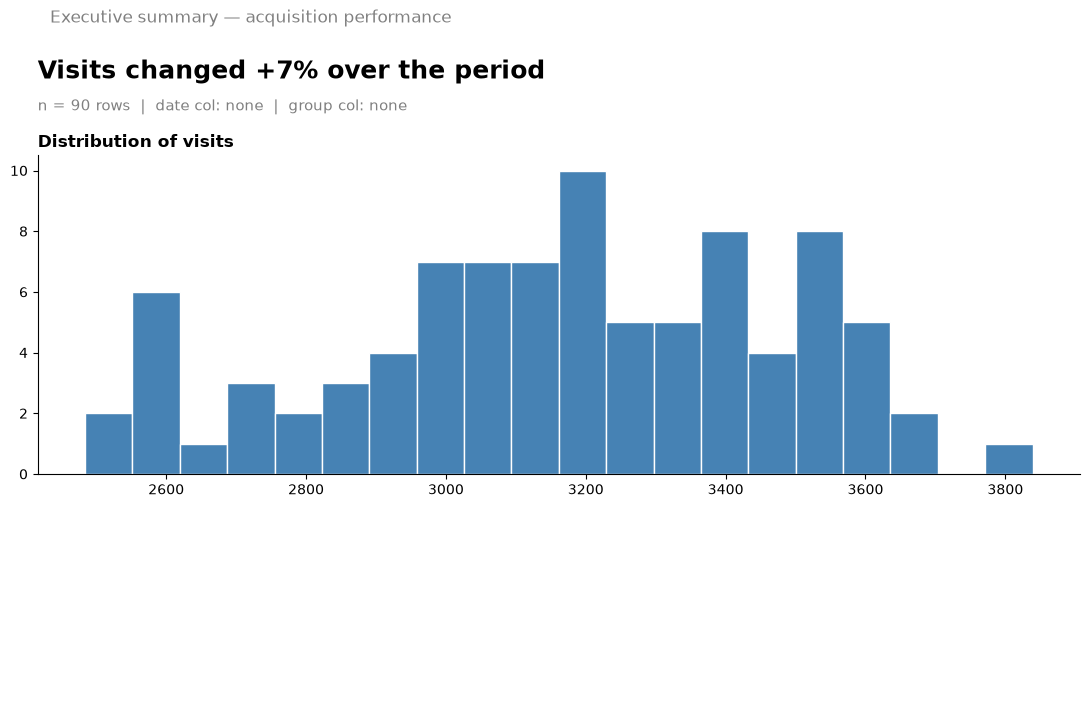

In [6]:
fig, axd = plt.subplot_mosaic(
    [['headline','headline'],
     ['main',    'main'    ],
     ['d1',      'd2'      ]],
    figsize=(11, 7),
    height_ratios=[0.5, 2.5, 1.4],
)

# Headline — always possible, with or without grouping
headline_axis = axd['headline']
headline_axis.axis('off')
if len(monthly) >= 2 and monthly[kpi].iloc[0] != 0:
    growth = (monthly[kpi].iloc[-1] / monthly[kpi].iloc[0] - 1) * 100
else:
    growth = 0
headline_axis.text(0.0, 0.6,
    f'{kpi.title()} changed {growth:+.0f}% over the period',
    fontsize=18, weight='bold', transform=headline_axis.transAxes)
headline_axis.text(0.0, 0.1,
    f'n = {len(df):,} rows  |  date col: {tcol or "none"}  |  group col: {grp or "none"}',
    fontsize=11, color='gray', transform=headline_axis.transAxes)

main_axis = axd['main']
main_axis.spines[['top','right']].set_visible(False)

if grp and tcol:
    pivot = monthly.pivot(index=tcol, columns=grp, values=kpi).fillna(0)
    pivot.plot.area(ax=main_axis, alpha=0.7, colormap='tab10')
    main_axis.set_title(f'{kpi.title()} over time, by {grp}', loc='left', weight='bold')
    main_axis.legend(frameon=False, loc='upper left')
    cols = list(pivot.columns)[:2]
    extra_axes = [(axd['d1'], axd['d2'], pivot)]
elif tcol:
    main_axis.plot(monthly[tcol], monthly[kpi], color='steelblue', lw=2)
    main_axis.set_title(f'{kpi.title()} over time', loc='left', weight='bold')
    cols, pivot = [], None
elif grp:
    pivot = monthly.set_index(grp)[kpi]
    pivot.plot.bar(ax=main_axis, color='steelblue')
    main_axis.set_title(f'{kpi.title()} by {grp}', loc='left', weight='bold')
    cols, pivot = [], None
else:
    main_axis.hist(monthly[kpi], bins=20, color='steelblue', edgecolor='white')
    main_axis.set_title(f'Distribution of {kpi}', loc='left', weight='bold')
    cols, pivot = [], None

if cols and pivot is not None:
    for ax, c in zip([axd['d1'], axd['d2']], cols):
        ax.plot(pivot.index, pivot[c], color='steelblue', marker='o', lw=2)
        ax.fill_between(pivot.index, pivot[c], color='steelblue', alpha=0.2)
        ax.set_title(c, loc='left', weight='bold')
        ax.spines[['top','right']].set_visible(False)
else:
    for ax in (axd['d1'], axd['d2']):
        ax.axis('off')

fig.suptitle('Executive summary — acquisition performance', x=0.05, ha='left',
             fontsize=12, color='gray', y=0.995)
plt.tight_layout(); plt.show()

## 5. Step 4 — design the dashboard layout

Four tabs:

| Tab | Contents |
|---|---|
| **Overview** | KPI tiles, headline chart, time range filter |
| **Channel** | Per-channel breakdown, bar chart, ranking |
| **Region** | Per-region breakdown, top contributors |
| **Funnel** | Conversion stages (if data permits) |

In [7]:
def shell(children):
    return html.Div(style={'fontFamily': 'system-ui', 'padding': '20px',
                            'backgroundColor': '#fafafa'}, children=children)

def kpi_card(label, value):
    return html.Div([
        html.Div(label, style={'color': '#666', 'fontSize': 12}),
        html.Div(value, style={'fontSize': 24, 'fontWeight': 'bold'}),
    ], style={'padding': '14px 18px', 'backgroundColor': 'white',
              'borderRadius': '8px', 'minWidth': '170px',
              'boxShadow': '0 1px 3px rgba(0,0,0,.04)'})
print('helpers defined')

helpers defined


In [8]:
def build_capstone_app(data, kpi, grp, tcol) -> dash.Dash:
    app = dash.Dash(__name__, suppress_callback_exceptions=True)
    channels = sorted(data[grp].dropna().unique()) if grp else []

    overview = html.Div([
        html.Div(id='kpi-row', style={'display': 'flex', 'gap': '12px'}),
        html.Div([
            html.Label('Time range'),
            dcc.DatePickerRange(id='date-range'),
        ], style={'marginTop': '16px'}),
        html.Div([
            dcc.Graph(id='line-chart', style={'flex': 2}),
            dcc.Graph(id='share-chart', style={'flex': 1}),
        ], style={'display': 'flex', 'gap': '12px', 'marginTop': '16px'}),
    ])

    channel = html.Div([
        dcc.Dropdown(id='ch-pick',
                     options=[{'label': c, 'value': c} for c in channels],
                     value=channels[0] if channels else None, clearable=False,
                     style={'width': '300px'}),
        dcc.Graph(id='ch-line'),
        dcc.Graph(id='ch-bar'),
    ])

    region_tab = html.Div([
        dcc.Graph(id='reg-bar'),
        dcc.Graph(id='reg-trend'),
    ])

    funnel_tab = html.Div([
        html.P('Funnel view — auto-derived if data contains stage-like column.',
               style={'color': 'gray'}),
        dcc.Graph(id='funnel'),
    ])

    app.layout = shell([
        html.H2('Growth Analytics — VP view'),
        html.P('Data: unified marketing daily', style={'color': 'gray'}),
        dcc.Tabs([
            dcc.Tab(overview,  label='Overview'),
            dcc.Tab(channel,   label='Channel'),
            dcc.Tab(region_tab,label='Region'),
            dcc.Tab(funnel_tab,label='Funnel'),
        ])
    ])

    @app.callback(
        [Output('kpi-row',   'children'),
         Output('line-chart','figure'),
         Output('share-chart','figure')],
        [Input('date-range','start_date'),
         Input('date-range','end_date')]
    )
    def update_overview(start, end):
        sub = data.copy()
        if tcol and start:
            sub = sub[sub[tcol] >= pd.to_datetime(start)]
        if tcol and end:
            sub = sub[sub[tcol] <= pd.to_datetime(end)]
        tiles = [
            kpi_card('Rows',        f'{len(sub):,}'),
            kpi_card(f'{kpi} (sum)', f'{sub[kpi].sum():,.0f}'),
            kpi_card(f'{kpi} (mean)',f'{sub[kpi].mean():,.1f}'),
            kpi_card(f'{kpi} (max)', f'{sub[kpi].max():,.0f}'),
        ]
        if tcol:
            monthly = sub.groupby([pd.Grouper(key=tcol, freq='W'), grp])[kpi].sum().reset_index()
            line_fig = px.line(monthly, x=tcol, y=kpi, color=grp,
                               title=f'Weekly {kpi} by {grp}')
            share = (sub.groupby(grp)[kpi].sum().reset_index()
                       .sort_values(kpi, ascending=False))
            share_fig = px.bar(share.head(10), x=grp, y=kpi, title=f'{kpi} share by {grp}')
        else:
            line_fig = px.line(title='No date column')
            share_fig = px.bar(title='No date column')
        return tiles, line_fig, share_fig

    @app.callback(
        [Output('ch-line', 'figure'),
         Output('ch-bar',  'figure')],
        Input('ch-pick', 'value')
    )
    def update_channel(c):
        sub = data[data[grp] == c] if c else data
        if tcol:
            line_fig = px.line(sub, x=tcol, y=kpi, title=f'{c} — {kpi} over time')
        else:
            line_fig = px.line(sub, y=kpi, title=f'{c} — {kpi}')
        bar_fig = px.bar(sub.head(30), x=tcol if tcol else data.columns[0], y=kpi,
                         title=f'{c} — recent values')
        return line_fig, bar_fig

    @app.callback(
        [Output('reg-bar',   'figure'),
         Output('reg-trend', 'figure')],
        Input('ch-pick', 'value'),   # reuse any input as a trigger
    )
    def update_region(_):
        agg = data.groupby(grp)[kpi].sum().reset_index().sort_values(kpi, ascending=False)
        bar_fig = px.bar(agg, x=grp, y=kpi, title=f'{kpi} by {grp}')
        if tcol:
            trend = data.groupby([pd.Grouper(key=tcol, freq='MS'), grp])[kpi].sum().reset_index()
            trend_fig = px.line(trend, x=tcol, y=kpi, color=grp, title='Monthly trend')
        else:
            trend_fig = px.line(title='No date column')
        return bar_fig, trend_fig

    @app.callback(Output('funnel', 'figure'), Input('ch-pick', 'value'))
    def update_funnel(_):
        if grp:
            sub = data.groupby(grp)[kpi].sum().reset_index().sort_values(kpi, ascending=False)
            return px.funnel(sub, y=grp, x=kpi, title=f'Funnel — {kpi} by {grp}')
        return px.funnel(title='No group column')
    return app

capstone = build_capstone_app(df, kpi, grp, tcol)
print('capstone app ready. Run: capstone.run(debug=True, port=8060)')

capstone app ready. Run: capstone.run(debug=True, port=8060)


In [9]:
if False:    # flip to True to start the server (blocks)
    capstone.run(debug=True, port=8060, jupyter_mode='inline')

## 6. Step 5 — ship the static assets

Even with a dashboard, the static executive chart should be exportable as PNG
and PDF for slide decks.

wrote reports/dataviz/exec_summary.{png,pdf}


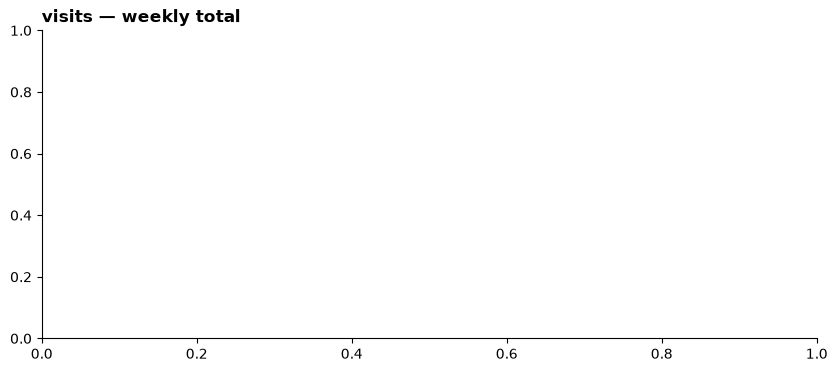

In [10]:
import os
os.makedirs('reports/dataviz', exist_ok=True)
fig_static, ax = plt.subplots(figsize=(10, 4))
if tcol:
    monthly_totals = df.groupby(pd.Grouper(key=tcol, freq='W'))[kpi].sum()
    ax.plot(monthly_totals.index, monthly_totals.values, marker='o', color='steelblue', lw=2)
    ax.fill_between(monthly_totals.index, monthly_totals.values, color='steelblue', alpha=0.2)
ax.set_title(f'{kpi} — weekly total', loc='left', weight='bold')
ax.spines[['top','right']].set_visible(False)
fig_static.savefig('reports/dataviz/exec_summary.png', dpi=200, bbox_inches='tight')
fig_static.savefig('reports/dataviz/exec_summary.pdf',           bbox_inches='tight')
print('wrote reports/dataviz/exec_summary.{png,pdf}')

## 7. Step 6 — package the app

Save the app as a runnable script. After this, the project has:

```
src/
  growth_dashboard.py    ← the app
  data_loader.py         ← load + validate data
  charts.py              ← reusable chart functions
data/
  clean/unified_daily.csv
reports/
  dataviz/
    exec_summary.png
    exec_summary.pdf
    sample.html
notebooks/
  data_visualization_course/14_capstone_growth_dashboard.ipynb  ← this file
```

In [11]:
import os, textwrap
os.makedirs('src', exist_ok=True)

loader_src = textwrap.dedent("""
    import os, pandas as pd
    
    DATA_PATH = os.path.join(os.path.dirname(__file__), '..', 'data', 'clean', 'unified_daily.csv')
    
    def load_unified() -> pd.DataFrame:
        df = pd.read_csv(DATA_PATH)
        for c in df.select_dtypes('object').columns:
            df[c] = df[c].astype('category')
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
        return df
""").strip()

app_src = textwrap.dedent("""
    import dash
    from dash import dcc, html
    from dash.dependencies import Input, Output
    import plotly.express as px
    from data_loader import load_unified
    
    app = dash.Dash(__name__)
    df = load_unified()
    KPI = 'spend' if 'spend' in df.columns else df.select_dtypes('number').columns[0]
    GRP = next((c for c in df.columns if df[c].dtype.name == 'category' and df[c].nunique() < 10), df.columns[0])
    
    app.layout = html.Div([
        html.H2('Growth dashboard'),
        dcc.Dropdown(id='grp', options=[{'label': c, 'value': c} for c in df[GRP].dropna().unique()],
                     value=df[GRP].dropna().unique()[0]),
        dcc.Graph(id='g'),
    ])
    
    @app.callback(Output('g', 'figure'), Input('grp', 'value'))
    def update(v):
        sub = df[df[GRP] == v]
        return px.line(sub, x='date' if 'date' in sub.columns else sub.columns[0], y=KPI)
    
    if __name__ == '__main__':
        app.run(debug=True, host='0.0.0.0', port=8050)
""").strip()

with open('src/data_loader.py', 'w') as f: f.write(loader_src + '\n')
with open('src/growth_dashboard.py', 'w') as f: f.write(app_src + '\n')
print('wrote src/data_loader.py and src/growth_dashboard.py')

wrote src/data_loader.py and src/growth_dashboard.py


## 8. Recap — what we used across the course

| Notebook | What you learned |
|---|---|
| 01 | Visual perception, Cleveland-McGill, Gestalt, chart selection |
| 02 | Figure / Axes / Artist, OO style, performance |
| 03 | Spines, ticks, rcParams, style sheets, legends |
| 04 | Histogram, KDE, box, violin, ECDF |
| 05 | Scatter, line, bar, area, slope |
| 06 | Bubble, heatmap, parallel coords, small multiples |
| 07 | Seaborn figure-level API |
| 08 | Plotly express + graph objects, animations |
| 09 | Mosaic, GridSpec, insets, twin axes |
| 10 | Annotations, reference lines, Big Idea |
| 11 | Color semantics, brand palette, typography |
| 12 | Waterfall, sankey, treemap, funnel, bump, calendar |
| 13 | Dash layout, callbacks, multi-page |
| 14 | **Capstone: load → design → ship a dashboard** |

You have used every chart type that shows up in a real growth-analytics
workflow. The rest is practice and taste.

## 9. Where to go next

- **Read** the references at the top of `00_course_index.ipynb`.
- **Re-skin** the capstone with your brand palette (notebook 11).
- **Add a map** view (see plotly `choropleth` / `scatter_geo`).
- **Wire it to a real API** — replace the CSV load with an HTTP call.
- **Deploy** with `uv run` on Render or Railway.
- **Add tests** — `pytest` with `dash.testing`.

When you can build a chart and *defend every choice you made* — palette,
encoding, label, axis, headline — you are a master.